#I. Setup & Imports

In [ ]:
# Environment Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

# Load Data
df = pd.read_csv('/content/train.csv')
print(f"Data Shape: {df.shape}")

Libraries imported successfully.
Data Shape: (511812, 17)


#II. Feature Engineering

In [ ]:
# --- A. Static Indicators ---
# 1. Imbalance Pressure (Directional strength of the imbalance)
df['imbalance_pressure'] = df['imbalance_size'] * df['imbalance_buy_sell_flag']

# 2. Spread (Market liquidity/tightness)
df['spread'] = df['ask_price'] - df['bid_price']

# 3. Auction Divergence (Theoretical vs Actual price)
df['auction_divergence'] = df['far_price'] - df['near_price']

# --- B. Dynamic Indicators (Time evolution) ---
cols_to_watch = ['imbalance_size', 'matched_size', 'reference_price', 'imbalance_pressure']
grouped = df.groupby(['stock_id', 'date_id'])

for col in cols_to_watch:
    df[f'{col}_diff'] = grouped[col].diff()

# Fill NaNs created by lags (start of day) with 0
df = df.fillna(0)

# --- C. Global Market Context ---
# We want to know if the "entire market" is buying or selling at this second.
global_stats = df.groupby(['date_id', 'seconds_in_bucket'])['imbalance_size'].mean().reset_index()
global_stats = global_stats.rename(columns={'imbalance_size': 'global_imbalance_mean'})

# Merge global stats back to main dataframe
df = df.merge(global_stats, on=['date_id', 'seconds_in_bucket'], how='left')

print("Feature Engineering Complete.")
display(df[['imbalance_size', 'imbalance_size_diff', 'global_imbalance_mean']].head())

Feature Engineering Complete.


,imbalance_size,imbalance_size_diff,global_imbalance_mean
0,3180602.69,0.0,7.625204e+06
1,166603.91,0.0,7.625204e+06
2,302879.87,0.0,7.625204e+06
3,11917682.27,0.0,7.625204e+06
4,447549.96,0.0,7.625204e+06


#III. Correlation Analysis

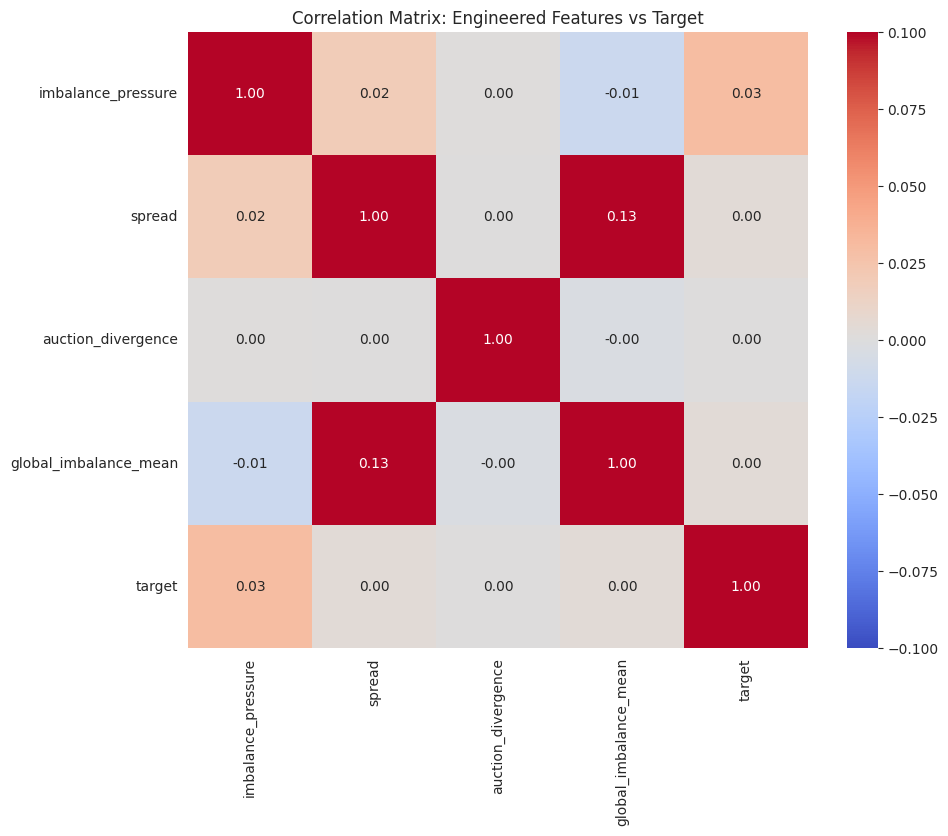

In [ ]:
# Correlation Check
df = df.sort_values(['date_id', 'seconds_in_bucket']).reset_index(drop=True)
features_to_check = ['imbalance_pressure', 'spread', 'auction_divergence', 'global_imbalance_mean', 'target']
corr_matrix = df[features_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1, fmt=".2f")
plt.title("Correlation Matrix: Engineered Features vs Target")
plt.show()

#IV. Model 1: Ridge Regression

Training on 409449 rows (Past)
Validating on 102363 rows (Future)
Ridge Results :
   MAE:  5.392609
   RMSE: 24.329153


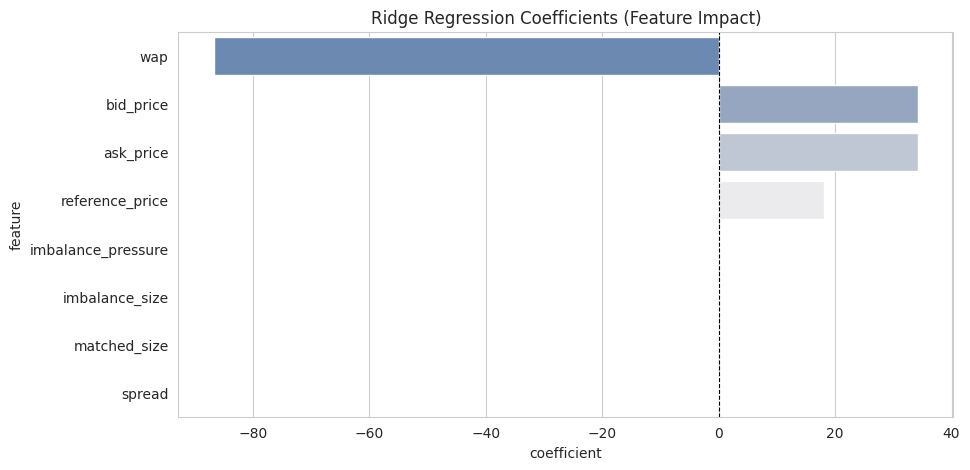

In [30]:
# IV.1 Feature Selection
ridge_features = [
    'bid_price', 'ask_price', 'wap', 'reference_price',
    'matched_size', 'imbalance_size',
    'imbalance_pressure', 'spread'
]

# IV.2 Handling NaNs (Required for Ridge)
# Create a clean copy to avoid modifying the original dataframe
valid_mask = df['target'].notna()
df_clean = df[valid_mask].copy()

X_ridge = df_clean[ridge_features]
y_ridge = df_clean['target']

# IV.3 Time-Series Split (Strict Chronological Cut)
# Keep the first 80% for training (Past), the last 20% for validation (Future)
split_point = int(len(df_clean) * 0.8)

X_train_r = X_ridge.iloc[:split_point]
y_train_r = y_ridge.iloc[:split_point]

X_val_r = X_ridge.iloc[split_point:]
y_val_r = y_ridge.iloc[split_point:]

print(f"Training on {len(X_train_r)} rows (Past)")
print(f"Validating on {len(X_val_r)} rows (Future)")

# IV.4 Pipeline & Training
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train_r, y_train_r)

# IV.5 Evaluation (MAE + RMSE)
y_pred_r = ridge_pipeline.predict(X_val_r)

mae_r = mean_absolute_error(y_val_r, y_pred_r)
rmse_r = np.sqrt(mean_squared_error(y_val_r, y_pred_r))

print(f"Ridge Results :")
print(f"   MAE:  {mae_r:.6f}")
print(f"   RMSE: {rmse_r:.6f}")

# IV.6 Feature Importance
coefs = pd.DataFrame({
    'feature': ridge_features,
    'coefficient': ridge_pipeline.named_steps['ridge'].coef_
})

coefs['abs_value'] = coefs['coefficient'].abs()
coefs = coefs.sort_values('abs_value', ascending=False).drop('abs_value', axis=1)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=coefs,
    x='coefficient',
    y='feature',
    palette='vlag', # Palette divergente car les coefs peuvent être négatifs
    hue='feature',
    legend=False
)
plt.title("Ridge Regression Coefficients (Feature Impact)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.show()

#V. Model 2: Random Forest

Random Forest MAE: 5.309104
   RMSE: 7.962850


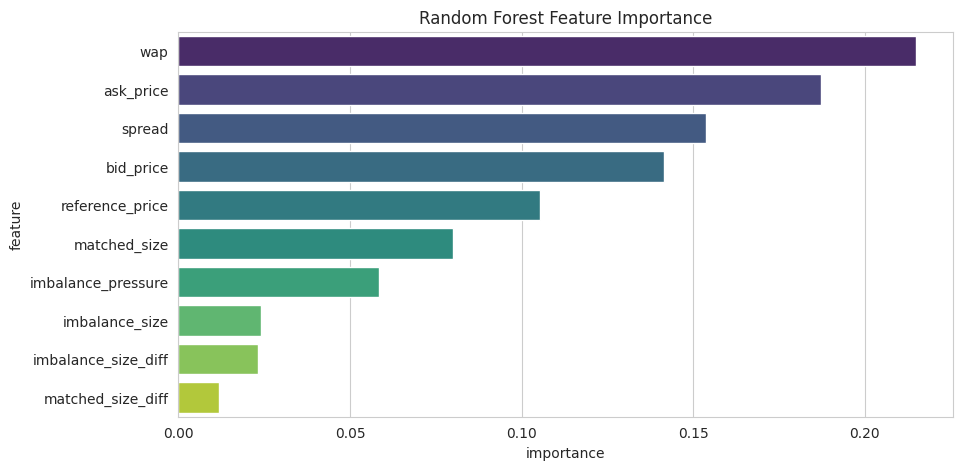

In [ ]:
# V.1 Sampling (To save memory/time)
MAX_RF_SAMPLES = 50000
if len(df) > MAX_RF_SAMPLES:
    df_rf = df.sample(n=MAX_RF_SAMPLES, random_state=42)
else:
    df_rf = df.copy()

# Reuse Ridge features + diffs for RF
rf_features = ridge_features + ['imbalance_size_diff', 'matched_size_diff']

X_rf = df_rf[rf_features]
y_rf = df_rf['target']

# Handle missing targets
X_rf = X_rf[y_rf.notna()]
y_rf = y_rf[y_rf.notna()]

X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# V.2 Training
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=8,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_rf, y_train_rf)

# V.3 Evaluation
y_pred_rf = rf_model.predict(X_val_rf)
mae_rf = mean_absolute_error(y_val_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val_rf, y_pred_rf))
print(f"Random Forest MAE: {mae_rf:.6f}")
print(f"   RMSE: {rmse_rf:.6f}")

# V.4 Feature Importance
importances = pd.DataFrame({
    'feature': rf_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
plt.title("Random Forest Feature Importance")
plt.show()

#VI. Model 3: LightGBM

Final Feature List (17 variables)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016206 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4083
[LightGBM] [Info] Number of data points in the train set: 460630, number of used features: 17
[LightGBM] [Info] Start training from score -0.050068
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 5.26501
[200]	valid_0's l1: 5.26171
[300]	valid_0's l1: 5.26094
Early stopping, best iteration is:
[265]	valid_0's l1: 5.26013
LightGBM MAE: 5.260126
LightGBM RMSE: 7.630974


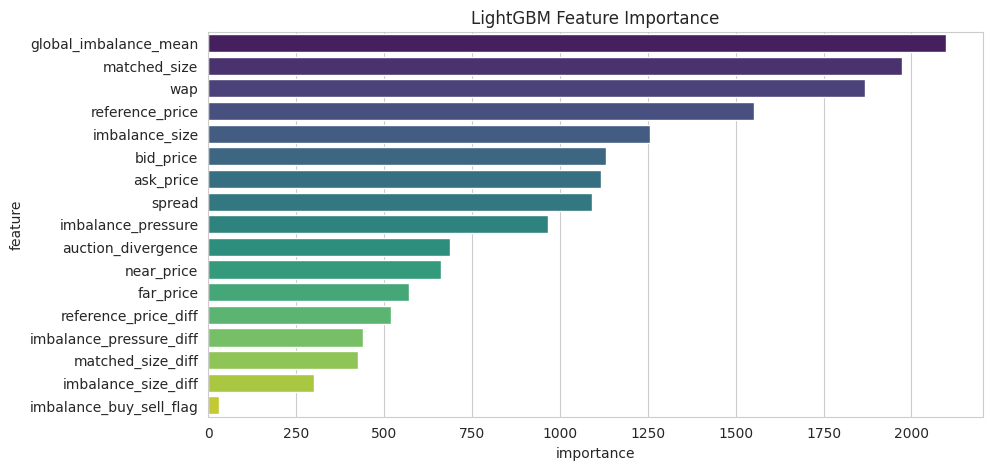

In [31]:
# VI.1 Feature List Preparation
# Base features + all Diff features + Global features
lgb_features = [
    'imbalance_size', 'imbalance_buy_sell_flag',
    'reference_price', 'matched_size',
    'far_price', 'near_price',
    'bid_price', 'ask_price', 'wap',
    'imbalance_pressure', 'spread', 'auction_divergence',
    'global_imbalance_mean'
]
# Add dynamic diff columns automatically
lgb_features += [col for col in df.columns if col.endswith('_diff')]

print(f"Final Feature List ({len(lgb_features)} variables)")

# VI.2 Time-Series Split (Crucial for Financial Data)
# We do not shuffle. We train on the past, test on the future.
split_index = int(len(df) * 0.9) # 90% Train, 10% Test

X_train_lgb = df[lgb_features].iloc[:split_index]
y_train_lgb = df['target'].iloc[:split_index]

X_test_lgb = df[lgb_features].iloc[split_index:]
y_test_lgb = df['target'].iloc[split_index:]

# VI.3 Configuration
params = {
    'objective': 'mae',
    'n_estimators': 3000,
    'learning_rate': 0.05,
    'num_leaves': 64,
    'random_state': 42,
    'n_jobs': -1
}

model = lgb.LGBMRegressor(**params)

# VI.4 Training with Early Stopping
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)
]

model.fit(
    X_train_lgb, y_train_lgb,
    eval_set=[(X_test_lgb, y_test_lgb)],
    eval_metric='mae',
    callbacks=callbacks
)

y_pred_lgb = model.predict(X_test_lgb)
lgb_mae = model.best_score_['valid_0']['l1']
rmse_lgb = np.sqrt(mean_squared_error(y_test_lgb, y_pred_lgb))

print(f"LightGBM MAE: {lgb_mae:.6f}")
print(f"LightGBM RMSE: {rmse_lgb:.6f}")

# VI.6 Feature Importance
importances_lgb = pd.DataFrame({
    'feature': lgb_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=importances_lgb,
    x='importance',
    y='feature',
    palette='viridis',
    hue='feature',
    legend=False
)
plt.title("LightGBM Feature Importance")
plt.show()

#VII. Final Comparison & Conclusion

In [32]:
print("-" * 65)
print("FINAL LEADERBOARD       (MAE)                    (RMSE)")
print("-" * 65)
print(f"{'1. LightGBM     ':<20} | {lgb_mae:.6f}               | {rmse_lgb:.6f}")
print(f"{'2. Random Forest':<20} | {mae_rf:.6f}               | {rmse_rf:.6f}")
print(f"{'3. Ridge':<20} | {mae_r:.6f}               | {rmse_r:.6f}")
print("-" * 65)
print("-" * 65)

-----------------------------------------------------------------
FINAL LEADERBOARD       (MAE)                    (RMSE)
-----------------------------------------------------------------
1. LightGBM          | 5.260126               | 7.630974
2. Random Forest     | 5.309104               | 7.962850
3. Ridge             | 5.392609               | 24.329153
-----------------------------------------------------------------
-----------------------------------------------------------------
